In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# =========================
# Config
# =========================
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# "conditional"  => score = -log p(z | x)
# "bayes"        => score = -log p(z) - log p(x | z)
LOSS_MODE = "conditional"

OBSERVED_SEQUENCE = [1, 1, 2, 5, 12, 27, 58, 121, 248, 503]

SYSTEM_PROMPT = (
    "You are a careful pattern-discovery assistant. "
    "Given an observed number sequence, propose a concise natural-language rule "
    "that likely generated it. Return only the rule, with no extra commentary."
)

def load_model_and_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        trust_remote_code=True,
    ).to(DEVICE)
    model.eval()
    return model, tokenizer

def render_chat(tokenizer, system_prompt: str, user_prompt: str) -> str:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

def continuation_nll(model, tokenizer, prefix: str, continuation: str) -> float:
    """
    Returns -log p(continuation | prefix)
    """
    with torch.no_grad():
        prefix_ids = tokenizer(
            prefix,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(DEVICE)

        full_ids = tokenizer(
            prefix + continuation,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(DEVICE)

        outputs = model(full_ids)
        logits = outputs.logits[:, :-1, :].float()
        labels = full_ids[:, 1:]

        log_probs = torch.log_softmax(logits, dim=-1)
        token_log_probs = log_probs.gather(2, labels.unsqueeze(-1)).squeeze(-1)

        start = prefix_ids.shape[1] - 1
        logp = token_log_probs[:, start:].sum().item()

    return -logp

def build_conditional_prefix(tokenizer, observed_sequence):
    seq_text = ", ".join(map(str, observed_sequence))
    user_prompt = (
        f"Observed sequence:\n{seq_text}\n\n"
        "What is the most likely concise rule that generated this sequence?"
    )
    return render_chat(tokenizer, SYSTEM_PROMPT, user_prompt)

def build_prior_prefix(tokenizer):
    system_prompt = (
        "You are a careful pattern-discovery assistant. "
        "Write a concise rule for a number sequence. "
        "Return only the rule."
    )
    user_prompt = "Write a rule to generate a number sequence."
    return render_chat(tokenizer, system_prompt, user_prompt)

def build_likelihood_prefix(tokenizer, explanation: str):
    system_prompt = (
        "You are a careful sequence predictor. "
        "Given a rule, continue the number sequence implied by that rule."
    )
    user_prompt = (
        f"Rule:\n{explanation}\n\n"
        "Output the first 10 terms of the sequence as comma-separated integers only."
    )
    return render_chat(tokenizer, system_prompt, user_prompt)

def generate_explanation(model, tokenizer, observed_sequence, max_new_tokens=80):
    prefix = build_conditional_prefix(tokenizer, observed_sequence)
    inputs = tokenizer(
        prefix,
        add_special_tokens=False,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = generated[:, prompt_len:]
    text = tokenizer.decode(gen_ids[0], skip_special_tokens=True).strip()
    return text

def score_explanation(model, tokenizer, observed_sequence, explanation: str, loss_mode: str, lam = 1):
    if loss_mode == "conditional":
        prefix = build_conditional_prefix(tokenizer, observed_sequence)
        loss = continuation_nll(model, tokenizer, prefix, explanation)
        return {
            "mode": "conditional",
            "loss": loss,
            "prior_nll": None,
            "likelihood_nll": None,
        }

    elif loss_mode == "bayes":
        seq_text = ", ".join(map(str, observed_sequence))

        prior_prefix = build_prior_prefix(tokenizer)
        prior_nll = continuation_nll(model, tokenizer, prior_prefix, explanation)

        likelihood_prefix = build_likelihood_prefix(tokenizer, explanation)
        likelihood_nll = continuation_nll(model, tokenizer, likelihood_prefix, seq_text)

        loss = lam*prior_nll + likelihood_nll
        return {
            "mode": "bayes",
            "loss": loss,
            "prior_nll": prior_nll,
            "likelihood_nll": likelihood_nll,
        }

    else:
        raise ValueError("loss_mode must be 'conditional' or 'bayes'")

In [ ]:
model, tokenizer = load_model_and_tokenizer(MODEL_NAME)

explanation = generate_explanation(model, tokenizer, OBSERVED_SEQUENCE)
score_conditional = score_explanation(model, tokenizer, OBSERVED_SEQUENCE, explanation, "conditional")
score_bayesian = score_explanation(model, tokenizer, OBSERVED_SEQUENCE, explanation, "bayes")

print("=== Observed sequence ===")
print(OBSERVED_SEQUENCE)

print("\n=== Generated explanation ===")
print(explanation)

print("\n=== Score ===")
print(f"mode: conditional")
print(f"loss: {score_conditional['loss']:.4f}")
print(f"mode: bayes")
print(f"loss: {score_bayesian['loss']:.4f}")
print(f"prior_nll: {score_bayesian['prior_nll']:.4f}")
print(f"likelihood_nll: {score_bayesian['likelihood_nll']:.4f}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Observed sequence ===
[1, 1, 2, 5, 12, 27, 58, 121, 248, 503]

=== Generated explanation ===
Each term is the sum of the previous term and twice the term before it.

=== Score ===
mode: conditional
loss: 2.3626
mode: bayes
loss: 64.4116
prior_nll: 23.6239
likelihood_nll: 40.7877


In [ ]:
OBSERVED_SEQUENCE = [1, 1, 2, 5, 12, 27, 58, 121, 248, 503]
concise_explanation = "2^n - n"
concise_explanation_ling = "Each term is 2 to the power of its index, minus its index."
dummy_explanation = f"the pattern is {OBSERVED_SEQUENCE}"
false_explanation = "3*n + 1"
max_likelihood_loss = explanation

In [ ]:
explanations_to_score = {
    "Concise explanation": concise_explanation,
    "Linguistic explanation": concise_explanation_ling,
    "Dummy explanation": dummy_explanation,
    "False explanation": false_explanation,
    "Max Likelihood": max_likelihood_loss,
}

for name, explanation in explanations_to_score.items():
    score_conditional = score_explanation(model, tokenizer, OBSERVED_SEQUENCE, explanation, "conditional")
    score_bayesian = score_explanation(model, tokenizer, OBSERVED_SEQUENCE, explanation, "bayes", 0.25)

    print(f"\n=== {name} ===")
    print(f"Explanation: {explanation}")
    print("\n=== Score ===")
    print(f"mode: conditional")
    print(f"loss: {score_conditional['loss']:.4f}\n")
    print(f"mode: bayes")
    print(f"loss: {score_bayesian['loss']:.4f}")
    print(f"prior_nll: {score_bayesian['prior_nll']:.4f}")
    print(f"likelihood_nll: {score_bayesian['likelihood_nll']:.4f}")


=== Concise explanation ===
Explanation: 2^n - n

=== Score ===
mode: conditional
loss: 39.3499

mode: bayes
loss: 27.4363
prior_nll: 38.9136
likelihood_nll: 17.7079

=== Linguistic explanation ===
Explanation: Each term is 2 to the power of its index, minus its index.

=== Score ===
mode: conditional
loss: 45.3845

mode: bayes
loss: 52.7721
prior_nll: 75.5515
likelihood_nll: 33.8842

=== Dummy explanation ===
Explanation: the pattern is [1, 1, 2, 5, 12, 27, 58, 121, 248, 503]

=== Score ===
mode: conditional
loss: 63.8752

mode: bayes
loss: 23.9444
prior_nll: 95.7698
likelihood_nll: 0.0019

=== False explanation ===
Explanation: 3*n + 1

=== Score ===
mode: conditional
loss: 42.2747

mode: bayes
loss: 67.8567
prior_nll: 34.4652
likelihood_nll: 59.2404

=== Max Likelihood ===
Explanation: Each term is the sum of the previous term and twice the term before it.

=== Score ===
mode: conditional
loss: 2.3626

mode: bayes
loss: 46.6937
prior_nll: 23.6239
likelihood_nll: 40.7877


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType
import torch
import torch.nn as nn
import random

# =========================
# Build policy (LoRA)
# =========================

def build_policy_model(model_name):
    base = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        trust_remote_code=True,
    ).to(DEVICE)

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
    )

    model = get_peft_model(base, lora_config)
    model.train()
    return model

# =========================
# Sampling (policy)
# =========================

def sample_explanation(model, tokenizer, observed_sequence, max_new_tokens=64):
    prefix = build_conditional_prefix(tokenizer, observed_sequence)

    inputs = tokenizer(
        prefix,
        return_tensors="pt",
        add_special_tokens=False
    ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            do_sample=True,
            temperature=0.8,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = output[:, prompt_len:]

    text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    return text, inputs["input_ids"], gen_ids

# =========================
# Logprob πθ(z|x)
# =========================

def policy_logprob(model, prompt_ids, gen_ids):
    full_ids = torch.cat([prompt_ids, gen_ids], dim=1)

    outputs = model(full_ids)
    logits = outputs.logits[:, :-1, :]
    labels = full_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(2, labels.unsqueeze(-1)).squeeze(-1)

    start = prompt_ids.shape[1] - 1
    return token_log_probs[:, start:].sum()


def encode_continuation(tokenizer, text):
    ids = tokenizer(
        text,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(DEVICE)
    return ids

# =========================
# REINFORCE loop
# =========================

policy_model = build_policy_model(MODEL_NAME)
evaluator_model = model

optimizer = torch.optim.AdamW(policy_model.parameters(), lr=5e-5)

baseline = None

NUM_EPISODES = 50
SAMPLES_PER_EPISODE = 4

# add before the loop
reward_history = []

for episode in range(NUM_EPISODES):

    rewards = []
    logprobs = []

    for i in range(SAMPLES_PER_EPISODE):

        z, prompt_ids, gen_ids = sample_explanation(
            policy_model, tokenizer, OBSERVED_SEQUENCE
        )

        if i == 1: # injection lol
          z = concise_explanation
          gen_ids = encode_continuation(tokenizer, z)

        score = score_explanation(
            evaluator_model, tokenizer, OBSERVED_SEQUENCE, z, "bayes", 0.30
        )

        reward = -score["loss"]  # IMPORTANT

        logprob = policy_logprob(policy_model, prompt_ids, gen_ids)

        rewards.append(reward)
        logprobs.append(logprob)

    rewards = torch.tensor(rewards, device=DEVICE)
    logprobs = torch.stack(logprobs)

    # baseline (batch mean)
    baseline = rewards.mean()
    reward_history.append(baseline)

    advantages = rewards - baseline

    loss = -(advantages.detach() * logprobs).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Episode {episode:03d} | reward mean {rewards.mean().item():.3f}")
    # for j, (r, lp) in enumerate(zip(rewards.tolist(), logprobs)):
    #     print(j, r)
    # print("baseline:", baseline.item())
    # print("advantages:", (rewards - baseline).tolist())

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Episode 000 | reward mean -48.339
Episode 001 | reward mean -43.915
Episode 002 | reward mean -45.673
Episode 003 | reward mean -43.915
Episode 004 | reward mean -38.472
Episode 005 | reward mean -36.748
Episode 006 | reward mean -38.907
Episode 007 | reward mean -37.345
Episode 008 | reward mean -40.207
Episode 009 | reward mean -43.752
Episode 010 | reward mean -35.404
Episode 011 | reward mean -41.599
Episode 012 | reward mean -38.603
Episode 013 | reward mean -37.458
Episode 014 | reward mean -46.968
Episode 015 | reward mean -49.285
Episode 016 | reward mean -46.290
Episode 017 | reward mean -44.758
Episode 018 | reward mean -35.911
Episode 019 | reward mean -41.100
Episode 020 | reward mean -36.861
Episode 021 | reward mean -37.308
Episode 022 | reward mean -35.911
Episode 023 | reward mean -35.911
Episode 024 | reward mean -35.911
Episode 025 | reward mean -36.244
Episode 026 | reward mean -41.401
Episode 027 | reward mean -50.321
Episode 028 | reward mean -46.046
Episode 029 | 

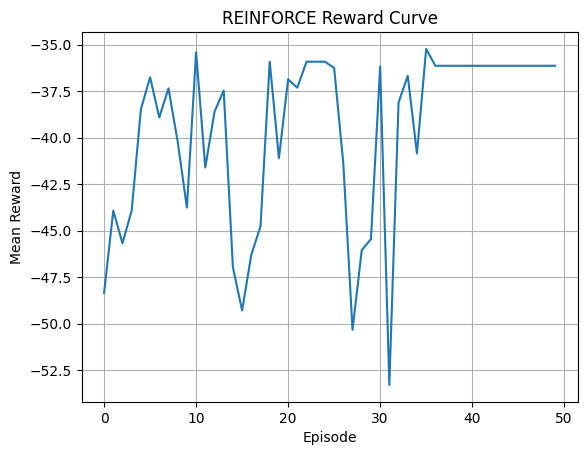

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
# Convert CUDA tensors to CPU and then to a list of numbers for plotting
plt.plot([r.cpu().item() for r in reward_history])
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.title("REINFORCE Reward Curve")
plt.grid(True)
plt.show()

In [ ]:
# base_model: original unfine-tuned model
# policy_model: fine-tuned LoRA model
# evaluator_model: frozen scorer
# tokenizer: shared tokenizer

base_model = model
base_model.eval()
policy_model.eval()


base_explanation = generate_explanation(base_model, tokenizer, OBSERVED_SEQUENCE)
ft_explanation = generate_explanation(policy_model, tokenizer, OBSERVED_SEQUENCE)

base_score = score_explanation(
    evaluator_model, tokenizer, OBSERVED_SEQUENCE, base_explanation, "bayes", 0.3
)
c_base_score = score_explanation(
    policy_model, tokenizer, OBSERVED_SEQUENCE, base_explanation, "conditional"
)

ft_score = score_explanation(
    evaluator_model, tokenizer, OBSERVED_SEQUENCE, ft_explanation, "bayes", 0.3
)
c_ft_score = score_explanation(
    policy_model, tokenizer, OBSERVED_SEQUENCE, ft_explanation, "conditional"
)

concise_score = score_explanation(
    evaluator_model, tokenizer, OBSERVED_SEQUENCE, concise_explanation, "bayes", 0.3
)
c_concise_score = score_explanation(
    policy_model, tokenizer, OBSERVED_SEQUENCE, concise_explanation, "conditional"
)

dummy_score = score_explanation(
    evaluator_model, tokenizer, OBSERVED_SEQUENCE, dummy_explanation, "bayes", 0.3
)
c_dummy_score = score_explanation(
    policy_model, tokenizer, OBSERVED_SEQUENCE, dummy_explanation, "conditional"
)

print("=== Observed sequence ===")
print(OBSERVED_SEQUENCE)

print("\n=== Base model explanation ===")
print(base_explanation)
print(f"Conditional loss: {c_base_score['loss']}\n")
print(f"Bayes loss: {base_score['loss']:.4f}")
print(f"prior_nll: {base_score['prior_nll']:.4f}")
print(f"likelihood_nll: {base_score['likelihood_nll']:.4f}")

print("\n=== Fine-tuned model explanation ===")
print(ft_explanation)
print(f"Conditional loss: {c_ft_score['loss']}\n")
print(f"Bayes loss: {ft_score['loss']:.4f}")
print(f"prior_nll: {ft_score['prior_nll']:.4f}")
print(f"likelihood_nll: {ft_score['likelihood_nll']:.4f}")


print("\n=== Correct explanation ===")
print(concise_explanation)
print(f"Conditional loss: {c_concise_score['loss']}\n")
print(f"Bayes loss: {concise_score['loss']:.4f}")
print(f"prior_nll: {concise_score['prior_nll']:.4f}")
print(f"likelihood_nll: {concise_score['likelihood_nll']:.4f}")

print("\n=== Dummy explanation ===")
print(dummy_explanation)
print(f"Conditional loss: {c_dummy_score['loss']}\n")
print(f"Bayes loss: {dummy_score['loss']:.4f}")
print(f"prior_nll: {dummy_score['prior_nll']:.4f}")
print(f"likelihood_nll: {dummy_score['likelihood_nll']:.4f}")



=== Observed sequence ===
[1, 1, 2, 5, 12, 27, 58, 121, 248, 503]

=== Base model explanation ===
Each term is the sum of the previous term and twice the term before it.
Conditional loss: 20.29422950744629

Bayes loss: 47.8749
prior_nll: 23.6239
likelihood_nll: 40.7877

=== Fine-tuned model explanation ===
2^n - n - 1
Conditional loss: 0.12719637155532837

Bayes loss: 38.3795
prior_nll: 39.7192
likelihood_nll: 26.4638

=== Correct explanation ===
2^n - n
Conditional loss: 0.09499770402908325

Bayes loss: 29.3820
prior_nll: 38.9136
likelihood_nll: 17.7079

=== Dummy explanation ===
the pattern is [1, 1, 2, 5, 12, 27, 58, 121, 248, 503]
Conditional loss: 41.54326248168945

Bayes loss: 28.7329
prior_nll: 95.7698
likelihood_nll: 0.0019


In [ ]:
explanation = generate_explanation(policy_model, tokenizer, OBSERVED_SEQUENCE)
score_conditional = score_explanation(policy_model, tokenizer, OBSERVED_SEQUENCE, explanation, "conditional")
score_bayesian = score_explanation(model, tokenizer, OBSERVED_SEQUENCE, explanation, "bayes", 0.3)

print("=== Observed sequence ===")
print(OBSERVED_SEQUENCE)
print("[User]: What is the most likely concise rule that generated this data?")
print("\n=== Generated explanation ===")
print(explanation)

print("\n=== Score ===")
print(f"mode: conditional")
print(f"loss: {score_conditional['loss']:.4f}")
print(f"mode: bayes")
print(f"loss: {score_bayesian['loss']:.4f}")
print(f"prior_nll: {score_bayesian['prior_nll']:.4f}")
print(f"likelihood_nll: {score_bayesian['likelihood_nll']:.4f}")

=== Observed sequence ===
[1, 1, 2, 5, 12, 27, 58, 121, 248, 503]
[User]: What is the most likely concise rule that generated this data?

=== Generated explanation ===
2^n - n - 1

=== Score ===
mode: conditional
loss: 0.1272
mode: bayes
loss: 38.3795
prior_nll: 39.7192
likelihood_nll: 26.4638


In [ ]:
import gc
import torch

try:
    del model
except:
    pass

try:
  del base_model
except:
  pass

try:
    del policy_model
except:
    pass

try:
    del evaluator_model
except:
    pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [ ]:
!nvidia-smi

Sun Apr 12 20:27:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   38C    P0             67W /  400W |   15442MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Multi Data Training

In [ ]:
import random
import torch
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForCausalLM, AutoTokenizer

# =========================
# Config
# =========================
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LR = 5e-5
NUM_EPISODES = 50
SAMPLES_PER_EXAMPLE = 4
TEMPERATURE = 1.0
MAX_NEW_TOKENS = 64

LAMBDA_PRIOR = 0.30
INJECTION_PROB = 0.25   # probability of replacing one sampled explanation with gold rule
GRAD_CLIP_NORM = 1.0

# =========================
# Placeholder training data
# Each item is: (observed_sequence, correct_rule)
# =========================
TRAIN_DATA = [
    ([1, 1, 2, 5, 12, 27, 58, 121, 248, 503], "2^n - n"),
    ([1, 4, 9, 16, 25, 36, 49, 64, 81, 100], "n^2"),
    ([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], "2^(n+1)"),
    ([1, 3, 6, 10, 15, 21, 28, 36, 45, 55], "n(n+1)/2"),
    ([1, 2, 4, 7, 11, 16, 22, 29, 37, 46], "1 + n(n+1)/2"),
]

# =========================
# Assumes you already have these from your earlier code:
# - load_model_and_tokenizer
# - render_chat
# - continuation_nll
# - build_conditional_prefix
# - build_prior_prefix
# - build_likelihood_prefix
# - score_explanation(model, tokenizer, observed_sequence, explanation, "bayes", lambda_prior)
# =========================

def build_policy_model(model_name: str):
    base = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        trust_remote_code=True,
    ).to(DEVICE)

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
    )

    model = get_peft_model(base, lora_config)
    model.train()
    return model


def encode_continuation(tokenizer, text: str):
    return tokenizer(
        text,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(DEVICE)


def sample_explanation(model, tokenizer, observed_sequence, max_new_tokens=64, temperature=1.0):
    prefix = build_conditional_prefix(tokenizer, observed_sequence)

    inputs = tokenizer(
        prefix,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = output[:, prompt_len:]
    text = tokenizer.decode(gen_ids[0], skip_special_tokens=True).strip()

    return text, inputs["input_ids"], gen_ids


def generate_explanation(model, tokenizer, observed_sequence, max_new_tokens=64):
    prefix = build_conditional_prefix(tokenizer, observed_sequence)

    inputs = tokenizer(
        prefix,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    gen_ids = output[:, prompt_len:]
    text = tokenizer.decode(gen_ids[0], skip_special_tokens=True).strip()
    return text


def policy_logprob(model, prompt_ids, gen_ids):
    full_ids = torch.cat([prompt_ids, gen_ids], dim=1)

    outputs = model(full_ids)
    logits = outputs.logits[:, :-1, :].float()
    labels = full_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(2, labels.unsqueeze(-1)).squeeze(-1)

    start = prompt_ids.shape[1] - 1
    return token_log_probs[:, start:].sum()


# =========================
# Init models
# =========================
policy_model = build_policy_model(MODEL_NAME)
evaluator_model, tokenizer = load_model_and_tokenizer(MODEL_NAME)
optimizer = torch.optim.AdamW(policy_model.parameters(), lr=LR)

# =========================
# Training loop
# =========================
for episode in range(NUM_EPISODES):
    policy_model.train()

    all_rewards = []
    all_logprobs = []

    sampled_examples = random.sample(TRAIN_DATA, k=min(len(TRAIN_DATA), len(TRAIN_DATA)))

    for observed_sequence, gold_rule in sampled_examples:
        inject_index = None
        if random.random() < INJECTION_PROB:
            inject_index = random.randrange(SAMPLES_PER_EXAMPLE)

        local_rewards = []
        local_logprobs = []

        for i in range(SAMPLES_PER_EXAMPLE):
            z, prompt_ids, gen_ids = sample_explanation(
                policy_model,
                tokenizer,
                observed_sequence,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
            )

            if inject_index is not None and i == inject_index:
                z = gold_rule
                gen_ids = encode_continuation(tokenizer, z)

            score = score_explanation(
                evaluator_model,
                tokenizer,
                observed_sequence,
                z,
                "bayes",
                LAMBDA_PRIOR,
            )

            reward = -score["loss"]
            logprob = policy_logprob(policy_model, prompt_ids, gen_ids)

            local_rewards.append(reward)
            local_logprobs.append(logprob)

        local_rewards = torch.tensor(local_rewards, device=DEVICE)
        local_logprobs = torch.stack(local_logprobs)

        baseline = local_rewards.mean()
        advantages = local_rewards - baseline

        all_rewards.append(local_rewards.mean().item())
        all_logprobs.append(-(advantages.detach() * local_logprobs).mean())

    loss = torch.stack(all_logprobs).mean()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_model.parameters(), GRAD_CLIP_NORM)
    optimizer.step()

    if (episode + 1) % 5 == 0 or episode == 0:
        avg_reward = sum(all_rewards) / len(all_rewards)

        print(f"\nEpisode {episode+1:03d}")
        print(f"Average reward: {avg_reward:.4f}")

        # quick qualitative check on 2 examples
        for seq, gold in TRAIN_DATA[:2]:
            pred = generate_explanation(policy_model, tokenizer, seq)
            pred_score = score_explanation(
                evaluator_model,
                tokenizer,
                seq,
                pred,
                "bayes",
                LAMBDA_PRIOR,
            )
            print(f"Sequence: {seq}")
            print(f"Gold: {gold}")
            print(f"Pred: {pred}")
            print(f"Bayes loss: {pred_score['loss']:.4f}")
            print("-" * 50)